In [5]:
import matplotlib.pyplot as plt
import numpy as np

from RunSimulator import RunSimulator
from PathPlotter import PathPlotter
master = RunSimulator()

"""
hi indira & tristan & whoever else it concerns
youll have to run this jupyter notebook from beginning prob
tips for jupyter notebook:
1) keep track of what you ran. try NOT to run cells out of order.
2) this may seem easier than normal coding but its actually like not. be careful.
3) fyi ipynbs are 'modified' if code OR cell output changes
"""

"\nhi indira & tristan & whoever else it concerns\nyoull have to run this jupyter notebook from beginning prob\ntips for jupyter notebook:\n1) keep track of what you ran. try NOT to run cells out of order.\n2) this may seem easier than normal coding but its actually like not. be careful.\n3) fyi ipynbs are 'modified' if code OR cell output changes\n"

In [6]:
#baseline constants
baseline_trial_num = 10
error_freq = 1
speed_noise_amplitude =0.1
headdir_noise_amplitude = 0.05
ts = 0.001
sim=20000
deltahead=2.4

#running trials!
master.baseline(baseline_trial_num, error_freq=error_freq,speed_noise_amplitude=speed_noise_amplitude,
                headdir_noise_amplitude=headdir_noise_amplitude, ts=ts, sim=sim, deltahead=deltahead)
baseline_final_drifts = master.all_final_drift
baseline_mean_errors = master.all_mean_error
baseline_rmses = master.all_rmse
baseline_errors_over_time = master.all_error_over_time


the mouse moved this far: 758.160114661234
[[ 517.02005384 -554.5241414 ]]
[ 548.50596183 -654.91619074]
the mouse moved this far: 544.1533809934106
[[ 468.88025083 -276.14165283]]
[ 432.25747648 -265.38883445]
the mouse moved this far: 637.7582267916165
[[ 530.15958439 -354.49452876]]
[ 491.0460148  -354.28543457]
the mouse moved this far: 543.6959867738152
[[531.42848844 114.84375347]]
[489.95057276 152.16875951]
the mouse moved this far: 667.9831783831961
[[583.36104341 325.40961823]]
[540.82146791 269.81124857]
the mouse moved this far: 600.7481049612221
[[568.75786668 193.42382144]]
[597.59840128 237.70597892]
the mouse moved this far: 636.4209164688335
[[ 617.79591687 -152.8390919 ]]
[677.76778676 -93.37692937]
the mouse moved this far: 676.9631729316751
[[ 642.63965824 -212.82247803]]
[ 468.03187909 -192.85608254]
the mouse moved this far: 828.8184858087642
[[582.67142844 589.43539841]]
[588.84361053 626.18595462]
the mouse moved this far: 207.1157358328997
[[-136.42911479 -155.

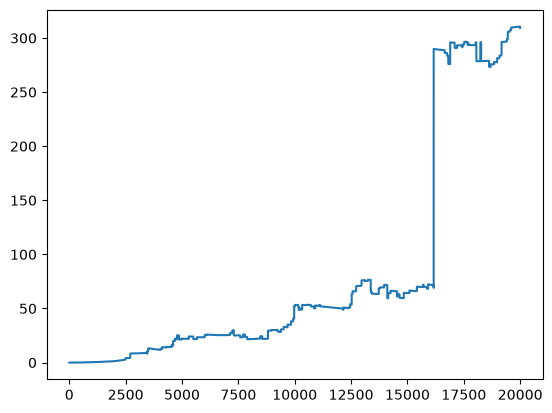

In [ ]:
#plot error over time
x = np.arange(sim) # this only works now in this specific case bc error_freq=1
y = np.mean(baseline_errors_over_time, axis=0)

plt.plot(x,y)
plt.show()

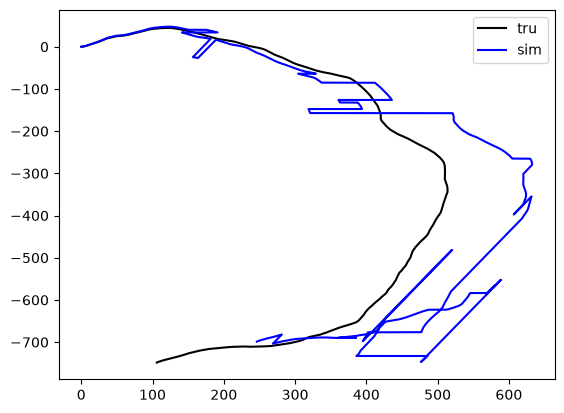

In [ ]:
#plot true path vs sim path over time

pathplotter = PathPlotter()
path_array = np.zeros((2,sim,2))
path_array[0] = master.trimmed_og_pos
path_array[1] = master.trimmed_sim_pos
pathplotter.paths(path_array, colors=["black", "blue"],labels=["tru", "sim"])



In [ ]:
#simulation time trial constants
simlen_trial_num = 3
simlen_iters = 10

error_freq = 1
speed_noise_amplitude =0.1
headdir_noise_amplitude = 0.05
ts = 0.001
sim_list=(np.arange(simlen_iters)+1)*10000
deltahead=2.4

#running trials!
sim_trial_final_drifts = np.zeros((simlen_iters,simlen_trial_num))
sim_trial_mean_errors = np.zeros((simlen_iters,simlen_trial_num))
sim_trial_rmses = np.zeros((simlen_iters,simlen_trial_num))
sim_trial_errors_over_time = [] #NOT a numpy array. its a 3d one, iter x simlen trial_num x floor(simlen/errorfreq)

for i in range(simlen_iters):
    master.baseline(simlen_trial_num, error_freq=error_freq,speed_noise_amplitude=speed_noise_amplitude,
                    headdir_noise_amplitude=headdir_noise_amplitude, ts=ts, sim=sim_list[i], deltahead=deltahead)
    sim_trial_final_drifts[i] = master.all_final_drift
    sim_trial_mean_errors[i] = master.all_mean_error
    sim_trial_rmses[i] = master.all_rmse
    sim_trial_errors_over_time.append(master.all_error_over_time)

the mouse moved this far: 189.70680437440106
[[ 150.66166051 -115.28111588]]
[ 133.63422026 -135.07609743]
the mouse moved this far: 151.1599069342414
[[131.3027745  -74.89258223]]
[143.34910402 -68.44901069]
the mouse moved this far: 373.2746587617404
[[ -44.90249226 -370.56407956]]
[ -68.01682345 -407.4532377 ]
the mouse moved this far: 651.2514966779997
[[632.30906933 155.92867848]]
[693.73116713 165.10797525]
the mouse moved this far: 232.01396754112335
[[180.13134584 146.22988539]]
[168.9520398  139.14049057]
the mouse moved this far: 246.8548235225601
[[  -8.2450135  -246.71709233]]
[  36.23128127 -256.90316516]
the mouse moved this far: 463.2045690199785
[[456.21333024 -80.17399873]]
[478.35838152 -76.05007208]
the mouse moved this far: 999.4835091218406


In [ ]:
print(sim_trial_final_drifts.shape)
print(sim_trial_mean_errors.shape)
print(sim_trial_rmses.shape)
print(f"{len(sim_trial_errors_over_time)}, {len(sim_trial_errors_over_time[0])}, {len(sim_trial_errors_over_time[0][0])}")

(10, 3)
(10, 3)
(10, 3)
10, 3, 10000


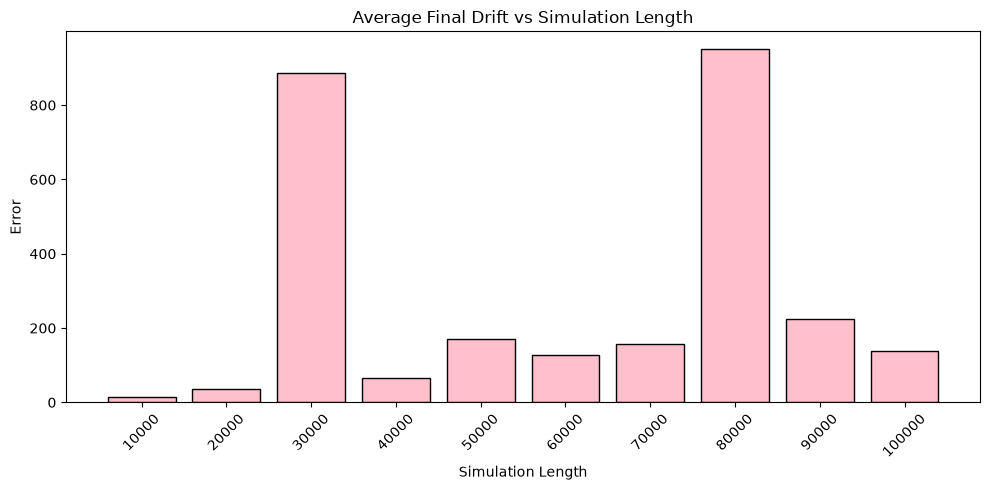

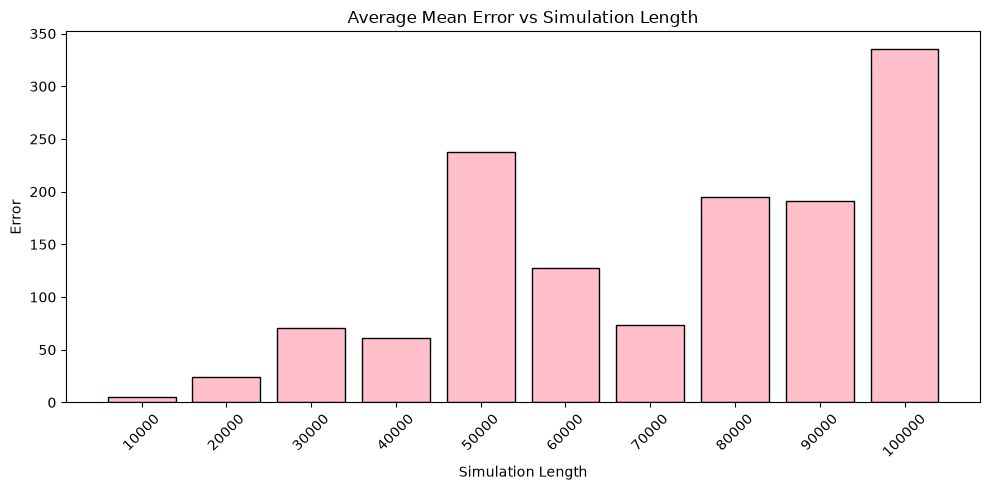

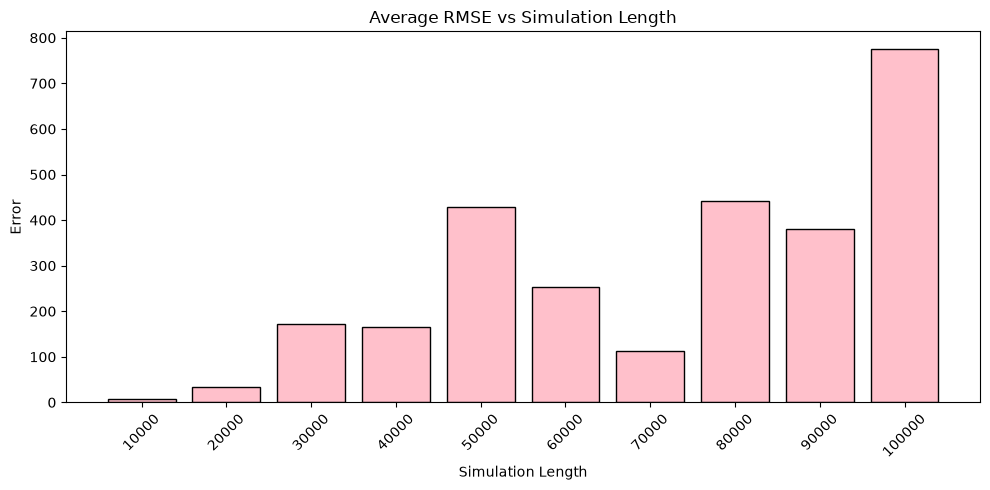

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x_labels = [f"{(i + 1) * 10000}" for i in range(10)]
x_pos = np.arange(len(x_labels))

avg_final_drifts = np.mean(sim_trial_final_drifts, axis=1)
avg_mean_errors = np.mean(sim_trial_mean_errors, axis=1)
avg_rmses = np.mean(sim_trial_rmses, axis=1)

sim_graphs = [
    ("Final Drift", avg_final_drifts),
    ("Mean Error", avg_mean_errors),
    ("RMSE", avg_rmses),
]

for title, data in sim_graphs:
    plt.figure(figsize=(10, 5))
    plt.bar(x_pos, data, color="pink", edgecolor="black")
    plt.xticks(x_pos, x_labels, rotation=45)
    plt.xlabel("Simulation Length")
    plt.ylabel("Error")
    plt.title(f"Average {title} vs Simulation Length")
    plt.tight_layout()
    plt.show()

In [ ]:
# module number trial . keep range the same from 25 cm to 22.6m
module_num_trial_num = 3
module_num_iters = range(5,14)
module_num_spacings = [np.power(2266./25., (1/i)) for i in module_num_iters]
module_num_len = len(module_num_iters)

error_freq = 1
speed_noise_amplitude =0.1
headdir_noise_amplitude = 0.05
ts = 0.001
sim = 20000
deltahead=2.4

#running trials!
module_num_final_drifts = np.zeros((module_num_len,module_num_trial_num))
module_num_mean_errors = np.zeros((module_num_len,module_num_trial_num))
module_num_rmses = np.zeros((module_num_len,module_num_trial_num))
module_num_errors_over_time = [] #NOT a numpy array. its a 3d one, len x trial_num x floor(simlen/errorfreq)

for i in range(module_num_len):
    master.baseline(module_num_len, error_freq=error_freq,speed_noise_amplitude=speed_noise_amplitude,
                    headdir_noise_amplitude=headdir_noise_amplitude, ts=ts, sim=sim, deltahead=deltahead,
                    NUM_OF_MODS=module_num_iters[i], spacing_min=25,spacing = module_num_spacings[i])
module_num_final_drifts[i] = master.all_final_drift
for i in range(module_num_len):
    master.baseline(module_num_trial_num, error_freq=error_freq,
                    speed_noise_amplitude=speed_noise_amplitude,
                    headdir_noise_amplitude=headdir_noise_amplitude, ts=ts,
                    sim=sim, deltahead=deltahead,
                    NUM_OF_MODS=module_num_iters[i], spacing_min=25,
                    spacing=module_num_spacings[i])
    module_num_final_drifts[i] = master.all_final_drift
    module_num_mean_errors[i] = master.all_mean_error
    module_num_rmses[i] = master.all_rmse
    module_num_errors_over_time.append(master.all_error_over_time)
module_num_rmses[i] = master.all_rmse
module_num_errors_over_time.append(master.all_error_over_time)

TypeError: RunSimulator.baseline() got an unexpected keyword argument 'spacing_min'

In [ ]:
"""tristan ... if you want can you make BAR charts of 
module_num_final_drifts, module_num_mean_errors, module_num_rmses
 (theres like 9 bars) 
x goes from 5 to 13
y is the error 
"""

In [ ]:
# module spacing trial..... do tmrw sophie
